# Let's make some 3-D random walks

Import the required libraries

In [1]:
%matplotlib inline 
from math import sin
from math import cos
from math import radians

import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #for plotting the 3-D plot.



I'm going to generate a set of points in the spherical coordinate system and convert them to caretesian coordinates

So ever point is represented as (r,theta,psi) where r is the step size and theta and psi are angles.
We generate two angles for each point, so R[i] and A[i] will represent the angles for point i and L[i] the magnitude

We generate the angles by getting a random number between 0-1 and multiply this by deg to get the degree range required.


In [2]:
deg = 120 #

for j in range(200):
    N = 10 #Number of steps in each random walk
    R = deg*(np.random.rand(N)) #Get the polar angles between. Picks random angle between 0-deg 
    A = deg*(np.random.rand(N)) #Get the azimethal angels. Picks random angle between 0-deg
    L = np.random.normal(100, 5, N)#Get the step size for each step, mean 100 std 5, N samples drawn
    
    flip_a = np.random.choice([-1,1], N) #Choose if the angle is positive or negative
    flip_r = np.random.choice([-1,1], N) #Choose if the angle is positive or negative
    
    for i in range(N):
        R[i] = R[i]*flip_r[i]
        A[i] = A[i]*flip_a[i]
    
    #We need to keep track of the change in angle over subsequent positions so the origin isn't reset at every point.
    R = np.cumsum(R)
    A = np.cumsum(A) 
    
    x = np.zeros(N)
    y = np.zeros(N)
    z = np.zeros(N)
    
    qc = np.ones(N)
    
    #Convert the first coordinate
    x[0] = L[0]*sin(radians(R[0]))*cos(radians(A[0]))
    y[0] = L[0]*sin(radians(R[0]))*sin(radians(A[0]))
    z[0] = L[0]*cos(radians(R[0]))
    
    for i in range(1,N):#converting spherical coordinates to cartesian.
        x[i] = x[i-1] + L[i]*sin(radians(R[i]))*cos(radians(A[i]))
        y[i] = y[i-1] + L[i]*sin(radians(R[i]))*sin(radians(A[i]))
        z[i] = z[i-1] + L[i]*cos(radians(R[i]))
    
    #Create 4xN dataframe in the format (x,y,z,QC)
    xyz_array = np.column_stack((x,y,z,qc))
    
    pd.DataFrame(xyz_array).to_csv("deg_" + str(deg) + "/trace_test" + str(j) + ".csv")

Setting deg will control the flexibility allowed at each step. So setting deg=30 will mean that -30 <= theta,psi <=30 and the traces will be saved in the folder deg_30.

The file format of the output x,y,z,qc output as a pandas dataframe

There should be 200 traces generated for deg={30,60,90,120}

Convert the points to cartesian coordinates

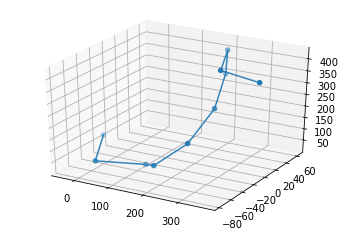

In [3]:
    #Plotting stuff
    plt.figure()
    ax = plt.subplot(1,1,1, projection='3d')
    ax.plot(x, y, z,alpha=0.9) #alpha sets the darkness of the path.
    ax.scatter(x,y,z)
    plt.show()